# Análise das Regiões que possuem as Maiores Rentabilidades

In [17]:
# Importa a biblioteca pandas para manipulação de dados
import pandas as pd
# Importa a biblioteca matplotlib para visualização de gráficos
import matplotlib.pyplot as plt
# Importa a biblioteca seaborn para visualização de gráficos mais avançados
import seaborn as sns
# Importa SparkSession para iniciar e gerenciar sessões Spark
from pyspark.sql import SparkSession
# Importa funções Spark para manipulação de colunas e expressões SQL
import pyspark.sql.functions as f

# Funções

In [18]:
def read_csv_dataset(path:str):
  """
  Read a csv file and return a pandas dataframe.
  ---
  path: string with the path to the csv file
  ---
  returns: pandas dataframe
  """
  return pd.read_csv(path)

def create_spark_df(spark_session, df:pd.DataFrame):
  return spark_session.createDataFrame(df)

def execute_sql(query:str, spark_session):
  return spark_session.sql(query)

In [19]:
# Cria ou obtém uma sessão Spark. Isso é necessário para trabalhar com DataFrames Spark e SQL.
spark_session = SparkSession.builder.getOrCreate()

In [20]:
# Define os caminhos para os arquivos CSV dos datasets de pedidos, itens e clientes.
orders_items_path = '/content/olist_order_items_dataset.csv'
orders_path = '/content/olist_orders_dataset.csv'
customers_path = '/content/olist_customers_dataset.csv'

In [21]:
def read_csv_dataset(path:str):
  """
  Lê um arquivo CSV e retorna um DataFrame pandas.
  ---
  path: string com o caminho para o arquivo CSV
  ---
  returns: pandas DataFrame
  """
  return pd.read_csv(path)

def create_spark_df(spark_session, df:pd.DataFrame):
  """
  Converte um DataFrame pandas em um DataFrame Spark.
  ---
  spark_session: A sessão Spark ativa
  df: DataFrame pandas a ser convertido
  ---
  returns: Spark DataFrame
  """
  return spark_session.createDataFrame(df)

def execute_sql(query:str, spark_session):
  """
  Executa uma query SQL usando a sessão Spark e retorna um DataFrame Spark.
  ---
  query: string com a query SQL a ser executada
  spark_session: A sessão Spark ativa
  ---
  returns: Spark DataFrame resultante da query
  """
  return spark_session.sql(query)

## Items

In [22]:
# Carrega o dataset de itens de pedido usando a função 'read_csv_dataset'
items = read_csv_dataset(orders_items_path)
# Converte o DataFrame pandas 'items' em um DataFrame Spark
items = create_spark_df(spark_session, items)

In [23]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Orders

In [24]:
# Carrega o dataset de pedidos usando a função 'read_csv_dataset'
orders = read_csv_dataset(orders_path)
# Converte o DataFrame pandas 'orders' em um DataFrame Spark
orders = create_spark_df(spark_session, orders)

## Customers

In [25]:
# Carrega o dataset de clientes usando a função 'read_csv_dataset'
customers = read_csv_dataset(customers_path)
# Converte o DataFrame pandas 'customers' em um DataFrame Spark
customers = create_spark_df(spark_session, customers)

## Transforming spark datasets into views to use SQL on them

In [26]:
# Cria views temporárias para os DataFrames Spark, permitindo o uso de queries SQL diretamente neles.
# 'fat_items' para o DataFrame de itens de pedido
fat_items = items.createOrReplaceTempView("fat_items")
# 'fat_orders' para o DataFrame de pedidos
fat_orders = orders.createOrReplaceTempView("fat_orders")
# 'dim_customers' para o DataFrame de clientes
dim_customers = customers.createOrReplaceTempView("dim_customers")

## Merging tables to make only one df

In [27]:
# Query SQL para juntar os DataFrames de itens, pedidos e clientes.
# Filtra apenas os pedidos com status 'delivered' (entregue) para garantir dados relevantes para a análise de lucro.
query = """
SELECT i.*, o.*, c.*
FROM fat_items i
INNER JOIN fat_orders o ON o.order_id = i.order_id
INNER JOIN dim_customers c ON c.customer_id = o.customer_id
WHERE o.order_status = 'delivered'
"""

# Executa a query SQL e armazena o resultado em um novo DataFrame Spark chamado 'df'
df = execute_sql(query, spark_session)

# Exibe as primeiras 20 linhas do DataFrame resultante, com 'truncate=False' para mostrar o conteúdo completo das colunas.
df.show(truncate=False)

+--------------------------------+-------------+--------------------------------+--------------------------------+-------------------+------+-------------+--------------------------------+--------------------------------+------------+------------------------+-------------------+----------------------------+-----------------------------+-----------------------------+--------------------------------+--------------------------------+------------------------+-------------------+--------------+
|order_id                        |order_item_id|product_id                      |seller_id                       |shipping_limit_date|price |freight_value|order_id                        |customer_id                     |order_status|order_purchase_timestamp|order_approved_at  |order_delivered_carrier_date|order_delivered_customer_date|order_estimated_delivery_date|customer_id                     |customer_unique_id              |customer_zip_code_prefix|customer_city      |customer_state|
+---------

In [28]:
# Adiciona uma coluna 'total_cost' arredondando o valor do frete (freight_value) para 3 casas decimais.
df = df.withColumn(
    "total_cost",
    f.round(f.col("freight_value"),3)
)

# Adiciona uma coluna 'profit' (lucro) calculando a diferença entre o preço do item e o custo total do frete,
# arredondando o resultado para 3 casas decimais.
df = df.withColumn(
    "profit",
    f.round(f.col("price") - f.col("total_cost"),3)
)

# Adiciona uma coluna 'profitability' (rentabilidade) calculando a porcentagem do lucro em relação ao preço do item,
# arredondando o resultado para 3 casas decimais e multiplicando por 100.
df = df.withColumn(
    "profitability",
    f.round(f.col("profit") / f.col("price"),3) * 100
)

In [29]:
# Agrupa o DataFrame 'df' pelo estado do cliente ('customer_state') e calcula a soma total do lucro ('profit') para cada estado.
# O resultado é armazenado em um novo DataFrame Spark 'df_profits', com a coluna de soma renomeada para 'profit_sum'.
df_profits = df.groupBy("customer_state") \
  .agg(f.sum("profit").alias("profit_sum"))

# Exibe o DataFrame 'df_profits' mostrando a soma do lucro por estado.
df_profits.show()

+--------------+------------------+
|customer_state|        profit_sum|
+--------------+------------------+
|            SC| 418896.4800000006|
|            RO|          34399.52|
|            PI|          64263.81|
|            AM|          16726.21|
|            RR| 5075.419999999999|
|            GO|231461.05000000002|
|            TO| 36797.64999999998|
|            MT|123158.82000000005|
|            SP|4365563.1700000055|
|            PB| 87335.09000000004|
|            ES| 219628.9700000001|
|            RS|  596322.150000002|
|            MS| 96492.38999999998|
|            AL| 63538.95000000001|
|            MG|  1286071.99000001|
|            PA|136917.60999999987|
|            BA| 396030.4699999982|
|            SE| 42859.25000000003|
|            PE|194806.92999999993|
|            CE| 173077.9900000001|
+--------------+------------------+
only showing top 20 rows


In [30]:
# Converte o DataFrame Spark 'df_profits' para um DataFrame pandas para facilitar a visualização com Matplotlib/Seaborn.
df_profits = df_profits.toPandas()

/tmp/ipykernel_12479/1848338851.py:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


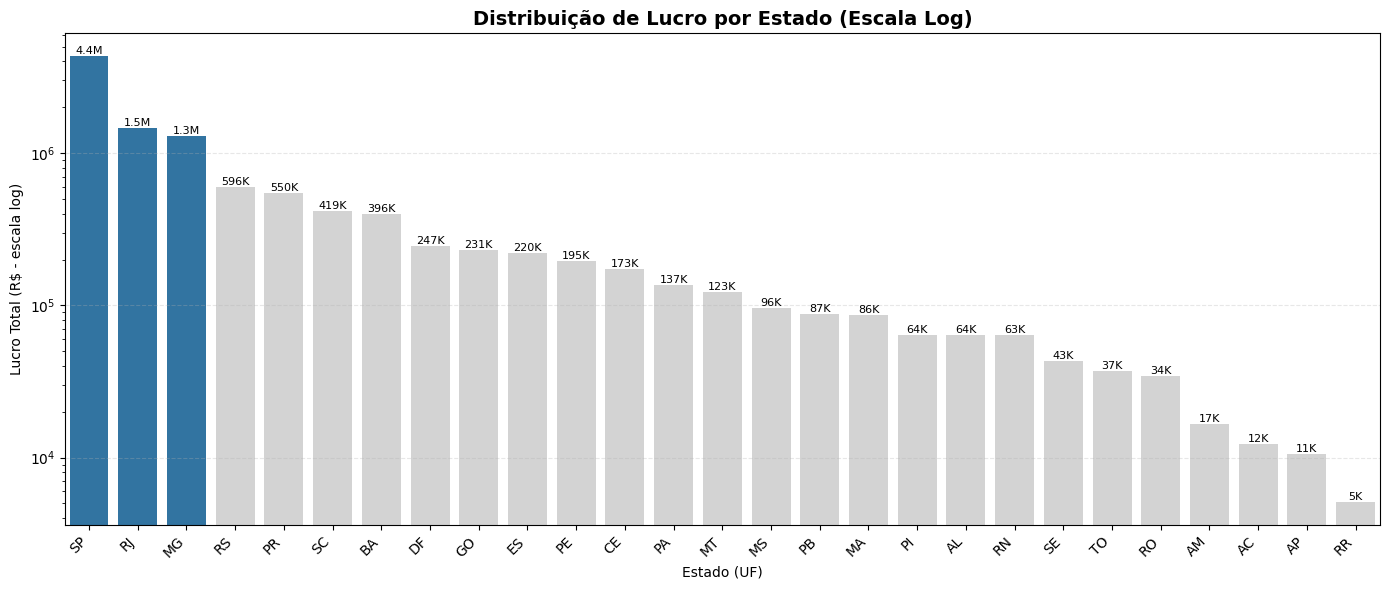

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns
import pyspark.sql.functions as f
from pyspark.sql import SparkSession

spark_session = SparkSession.builder.getOrCreate()

def execute_sql(query: str, spark_session):
    return spark_session.sql(query)

# Query
query = """
SELECT i.*, o.*, c.*
FROM fat_items i
INNER JOIN fat_orders o ON o.order_id = i.order_id
INNER JOIN dim_customers c ON c.customer_id = o.customer_id
WHERE o.order_status = 'delivered'
"""
df = execute_sql(query, spark_session)

# Feature Engineering (EDA + Business)
df = df.withColumn("total_cost", f.round(f.col("freight_value"), 3))

df = df.withColumn(
    "profit",
    f.round(f.col("price") - f.col("total_cost"), 3)
)

df = df.withColumn(
    "profitability",
    f.round((f.col("profit") / f.col("price")) * 100, 3)
)

# Agregação
df_profits_spark = df.groupBy("customer_state") \
    .agg(f.sum("profit").alias("profit_sum"))

df_profits = df_profits_spark.toPandas()

# ⚠️ Remover valores <= 0 para usar log
df_profits = df_profits[df_profits["profit_sum"] > 0]

# Ordenação
df_profits_sorted = df_profits.sort_values(by='profit_sum', ascending=False)

# Ranking para cores
df_profits_sorted['rank'] = range(len(df_profits_sorted))

# Cores: Top 3 destaque
cores = [
    '#1f77b4' if i < 3 else '#d3d3d3'
    for i in df_profits_sorted['rank']
]

# 🔥 FUNÇÃO CORRIGIDA (dinâmica)
def format_profit(value):
    if value >= 1_000_000:
        return f'{value/1e6:.1f}M'
    elif value >= 1_000:
        return f'{value/1e3:.0f}K'
    else:
        return f'{value:.0f}'

# Plot
plt.figure(figsize=(14, 6))

ax = sns.barplot(
    data=df_profits_sorted,
    x='customer_state',
    y='profit_sum',
    palette=cores
)

# Escala log
plt.yscale('log')

# Título
plt.title('Distribuição de Lucro por Estado (Escala Log)', fontsize=14, weight='bold')
plt.xlabel('Estado (UF)')
plt.ylabel('Lucro Total (R$ - escala log)')

# Rotação labels eixo X
plt.xticks(rotation=45, ha='right')

# Labels nas barras
for p in ax.patches:
    valor = p.get_height()
    ax.annotate(
        format_profit(valor),
        (p.get_x() + p.get_width() / 2., valor),
        ha='center',
        va='bottom',
        fontsize=8
    )

# Grid suave
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

In [32]:
# Define o caminho para o arquivo CSV do dataset de produtos.
products_path = '/content/olist_products_dataset.csv'
# Carrega o dataset de produtos usando a função 'read_csv_dataset'.
products = read_csv_dataset(products_path)
# Converte o DataFrame pandas 'products' em um DataFrame Spark.
products = create_spark_df(spark_session, products)
# Cria uma view temporária para o DataFrame Spark 'products', chamada 'dim_products', para uso em queries SQL.
products.createOrReplaceTempView("dim_products")
print("Products dataset loaded and view created.")

Products dataset loaded and view created.


In [33]:
# Query SQL para juntar os DataFrames de itens, pedidos, clientes e agora também produtos.
# Inclui a categoria do produto ('product_category_name') na seleção.
# Filtra apenas os pedidos com status 'delivered' (entregue).
query_with_products = """
SELECT i.*, o.*, c.*, p.product_category_name
FROM fat_items i
INNER JOIN fat_orders o ON o.order_id = i.order_id
INNER JOIN dim_customers c ON c.customer_id = o.customer_id
INNER JOIN dim_products p ON p.product_id = i.product_id
WHERE o.order_status = 'delivered'
"""
# Executa a query SQL e armazena o resultado em um novo DataFrame Spark 'df_with_products'.
df_with_products = execute_sql(query_with_products, spark_session)

# Adiciona uma coluna 'total_cost' arredondando o valor do frete para 3 casas decimais.
df_with_products = df_with_products.withColumn(
    "total_cost",
    f.round(f.col("freight_value"),3)
)

# Adiciona uma coluna 'profit' (lucro) calculando a diferença entre o preço do item e o custo total do frete,
# arredondando o resultado para 3 casas decimais.
df_with_products = df_with_products.withColumn(
    "profit",
    f.round(f.col("price") - f.col("total_cost"),3)
)

# Adiciona uma coluna 'profitability' (rentabilidade) calculando a porcentagem do lucro em relação ao preço do item,
# arredondando o resultado para 3 casas decimais e multiplicando por 100.
df_with_products = df_with_products.withColumn(
    "profitability",
    f.round(f.col("profit") / f.col("price"),3) * 100
)

print("DataFrame with products and profit metrics created.")
# Exibe as primeiras 20 linhas do DataFrame resultante, com 'truncate=False' para mostrar o conteúdo completo das colunas.
df_with_products.show(truncate=False)

DataFrame with products and profit metrics created.
+--------------------------------+-------------+--------------------------------+--------------------------------+-------------------+------+-------------+--------------------------------+--------------------------------+------------+------------------------+-------------------+----------------------------+-----------------------------+-----------------------------+--------------------------------+--------------------------------+------------------------+-------------------+--------------+---------------------------+----------+------+------------------+
|order_id                        |order_item_id|product_id                      |seller_id                       |shipping_limit_date|price |freight_value|order_id                        |customer_id                     |order_status|order_purchase_timestamp|order_approved_at  |order_delivered_carrier_date|order_delivered_customer_date|order_estimated_delivery_date|customer_id         

In [34]:
# Agrupa o DataFrame 'df_with_products' pelo estado do cliente ('customer_state') e pela categoria do produto ('product_category_name').
# Calcula a soma total do lucro ('profit') para cada combinação de estado e categoria.
# Ordena os resultados em ordem decrescente pela soma do lucro ('profit_sum').
df_profits_by_state_category = df_with_products.groupBy("customer_state", "product_category_name") \
  .agg(f.sum("profit").alias("profit_sum")) \
  .orderBy(f.col("profit_sum").desc())

print("Profits by state and product category:")
# Exibe as primeiras 20 linhas do DataFrame resultante, com 'truncate=False'.
df_profits_by_state_category.show(truncate=False)

Profits by state and product category:
+--------------+----------------------+------------------+
|customer_state|product_category_name |profit_sum        |
+--------------+----------------------+------------------+
|SP            |beleza_saude          |397577.5799999994 |
|SP            |cama_mesa_banho       |395414.2500000001 |
|SP            |relogios_presentes    |394510.4399999998 |
|SP            |esporte_lazer         |321877.29000000004|
|SP            |informatica_acessorios|295809.27000000014|
|SP            |moveis_decoracao      |222558.39999999985|
|SP            |utilidades_domesticas |215916.89000000013|
|SP            |cool_stuff            |186676.41999999993|
|SP            |automotivo            |183456.2200000001 |
|RJ            |relogios_presentes    |161525.18         |
|SP            |brinquedos            |155220.14000000007|
|SP            |perfumaria            |144332.85999999987|
|MG            |beleza_saude          |133640.77999999997|
|SP            |b

## Análise de Rentabilidade por Estado e Categoria de Produto

Agora temos uma visão mais detalhada da rentabilidade, segmentada por estado e categoria de produto. Isso nos permite identificar quais categorias performam melhor em cada região, fornecendo insights mais granulares para estratégias de negócios.

<h1><font color="red">Ticket Médio por Região </font></h1>

In [35]:
# Calcula o ticket médio por estado usando Spark SQL.
# Agrupa o DataFrame 'df' pelo estado do cliente ('customer_state') e calcula a média do preço ('price') para cada estado.
ticket_medio_spark = df.groupBy('customer_state').agg(f.mean('price').alias('average_price'))
# Ordena os resultados em ordem decrescente pelo ticket médio.
ticket_medio_spark = ticket_medio_spark.orderBy(f.desc('average_price'))

print("Estados com maior Ticket Médio (Spark):")
# Exibe o DataFrame Spark resultante.
ticket_medio_spark.show()

Estados com maior Ticket Médio (Spark):
+--------------+------------------+
|customer_state|     average_price|
+--------------+------------------+
|            PB|192.12767918088767|
|            AL|184.67381733021105|
|            AC|175.06560439560428|
|            RO|167.33611721611734|
|            PA|165.53186907020878|
|            AP|165.12111111111105|
|            PI|161.99043977055476|
|            RN|157.59243761996186|
|            TO|156.13712903225823|
|            CE|  154.107559607293|
|            RR| 153.4232608695652|
|            SE|  150.864506666667|
|            MT|146.76144648023143|
|            MA|146.26172500000027|
|            PE|144.26660366552096|
|            MS|142.33041923551193|
|            AM|135.92539877300604|
|            BA|134.01687211512169|
|            DF|125.90166029723903|
|            RJ|124.41852011596224|
+--------------+------------------+
only showing top 20 rows


## Análise dos Resultados: Rentabilidade e Ticket Médio por Estado

Com base nos gráficos de "Rentabilidade Total (Receita Bruta) por Estado" e "Ticket Médio por Estado", podemos extrair as seguintes conclusões:

### Rentabilidade Total por Estado:

O estado de **São Paulo (SP)** apresenta a maior rentabilidade total, superando significativamente os demais estados. Isso pode ser atribuído a um volume de vendas muito superior em comparação com outras regiões. Outros estados com rentabilidade notável incluem **Minas Gerais (MG)** e **Rio Grande do Sul (RS)**, que aparecem em segundo e terceiro lugar, respectivamente.

### Ticket Médio por Estado:

No que diz respeito ao ticket médio (o valor médio gasto por pedido), os estados que se destacam são **Paraíba (PB)** e **Alagoas (AL)**. Embora não sejam os líderes em rentabilidade total, um alto ticket médio pode indicar clientes que realizam compras de maior valor unitário, o que pode ser interessante para estratégias de produtos premium ou de maior valor agregado, mesmo que o volume de pedidos seja menor. Estados como **Acre (AC)** e **Rondônia (RO)** também mostram um ticket médio elevado.

### Considerações Finais:

*   **São Paulo** é o motor de rentabilidade, provavelmente impulsionado pelo volume. Estratégias para este estado devem focar na manutenção e expansão da base de clientes e otimização logística para lidar com o alto volume.
*   Estados com **alto ticket médio (PB, AL, AC, RO)**, apesar de menor rentabilidade total, representam uma oportunidade para estratégias de upselling, cross-selling ou foco em produtos de maior margem. A análise do perfil de compra nesses estados pode revelar preferências por produtos mais caros ou específicos.
*   É importante notar que a "rentabilidade" aqui foi calculada como `preço - custo do frete`. Para uma análise mais aprofundada, seria ideal considerar outros custos operacionais e o custo dos produtos.


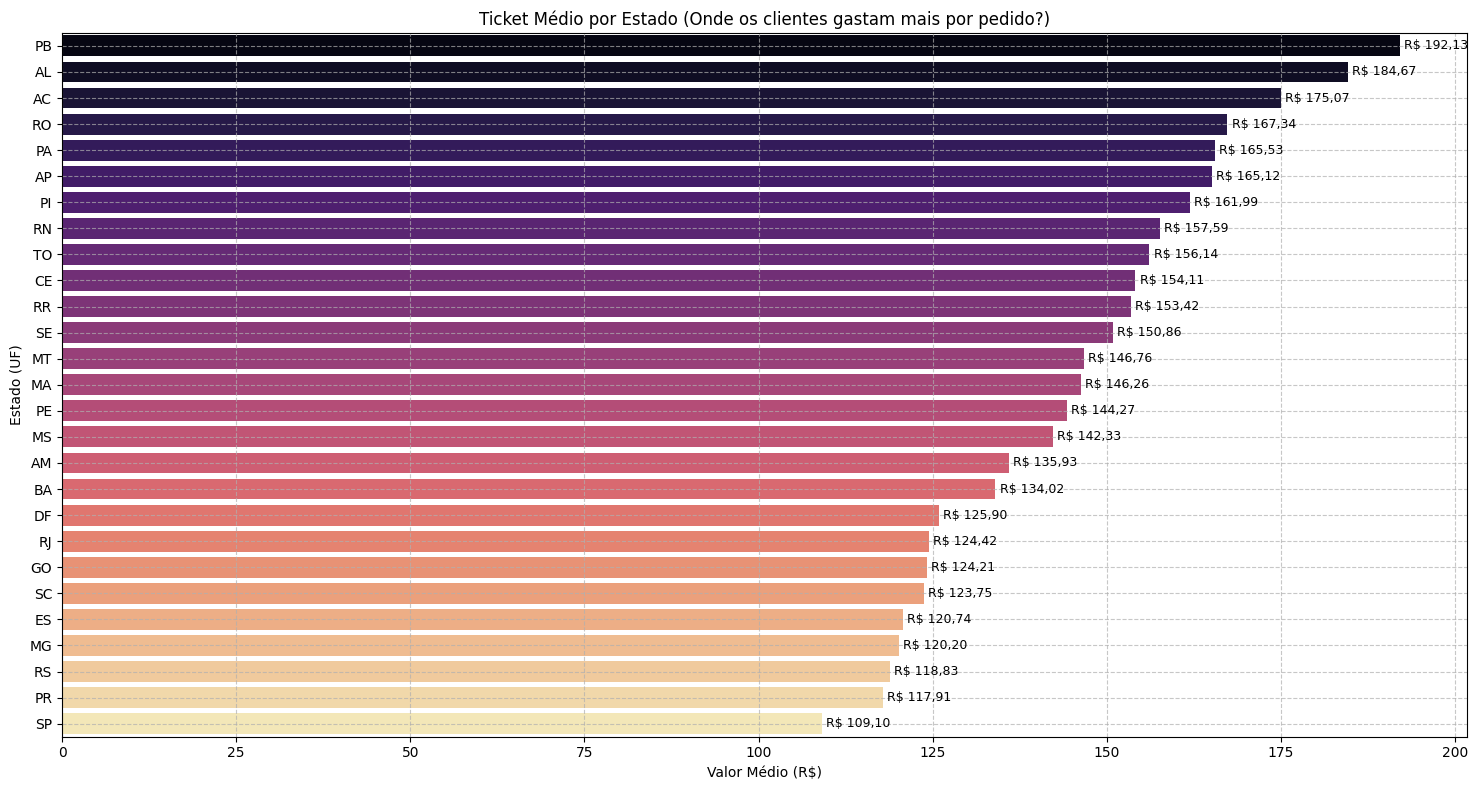

In [36]:
# Converte o DataFrame Spark 'ticket_medio_spark' para um DataFrame pandas para facilitar a visualização com Matplotlib/Seaborn.
ticket_medio_df_pandas = ticket_medio_spark.toPandas()

# Cria uma figura para o gráfico com tamanho ampliado para melhor visualização dos rótulos.
plt.figure(figsize=(15, 8))
# Cria um gráfico de barras horizontal usando seaborn, mostrando o ticket médio por estado.
# 'y' é o estado do cliente, 'x' é o preço médio, 'hue' é usado para colorir as barras por estado, e a legenda é desativada.
ax = sns.barplot(data=ticket_medio_df_pandas, y='customer_state', x='average_price', hue='customer_state', legend=False, palette='magma')
# Define o título do gráfico.
plt.title('Ticket Médio por Estado (Onde os clientes gastam mais por pedido?)')
# Define o rótulo do eixo X.
plt.xlabel('Valor Médio (R$)')
# Define o rótulo do eixo Y.
plt.ylabel('Estado (UF)')
# Adiciona uma grade no eixo X para facilitar a leitura.
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Adiciona rótulos de dados em cada barra para exibir o valor exato do ticket médio.
for container in ax.containers:
    ax.bar_label(container, fmt=lambda x: f'R$ {x:,.2f}'.replace(',', '_TEMP_').replace('.', ',').replace('_TEMP_', '.'), padding=3, fontsize=9) # Formata como moeda brasileira e ajusta padding/fontsize

# Adiciona uma grade no eixo Y para facilitar a leitura.
plt.grid(axis='y', linestyle='--', alpha=0.7)
# Ajusta automaticamente o layout da figura para evitar sobreposições de elementos.
plt.tight_layout()
# Exibe o gráfico.
plt.show()